<!-- 01_data_exploration.ipynb -->

In [163]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/Yangon_Weather_2015_2024.csv"
)

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

         date         location                    station_reference  \
0  2015-01-01  Yangon, Myanmar  Yangon International Airport (VYYY)   
1  2015-01-02  Yangon, Myanmar  Yangon International Airport (VYYY)   
2  2015-01-03  Yangon, Myanmar  Yangon International Airport (VYYY)   
3  2015-01-04  Yangon, Myanmar  Yangon International Airport (VYYY)   
4  2015-01-05  Yangon, Myanmar  Yangon International Airport (VYYY)   

   temperature_avg_c  temperature_min_c  temperature_max_c  dew_point_c  \
0              23.18              19.24              28.96        19.98   
1              25.16              21.42              29.97        20.25   
2              25.55              21.51              29.85        23.84   
3              24.46              21.08              29.55        23.00   
4              23.21              19.04              28.62        21.22   

   relative_humidity_pct  precipitation_mm  snow_depth_mm  ...  \
0                   77.4               0.0              

In [164]:
print(df.shape)

(3653, 23)


In [165]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    3653 non-null   str    
 1   location                3653 non-null   str    
 2   station_reference       3653 non-null   str    
 3   temperature_avg_c       3653 non-null   float64
 4   temperature_min_c       3653 non-null   float64
 5   temperature_max_c       3653 non-null   float64
 6   dew_point_c             3610 non-null   float64
 7   relative_humidity_pct   3617 non-null   float64
 8   precipitation_mm        3624 non-null   float64
 9   snow_depth_mm           3653 non-null   int64  
 10  wind_direction_deg      3617 non-null   float64
 11  wind_speed_kmh          3610 non-null   float64
 12  peak_wind_gust_kmh      3599 non-null   float64
 13  sea_level_pressure_hpa  3617 non-null   float64
 14  sunshine_minutes        3588 non-null   float64
 15

<!-- 02_data_preprocessing.ipynb -->

<!-- convert date -->

In [166]:
df["date"] = pd.to_datetime(df["date"])

In [167]:
df = df.sort_values("date")

<!-- check duplicate -->

In [168]:
df.duplicated().sum()

np.int64(0)

<!-- check missing values -->

In [169]:
df.isnull().sum()

date                       0
location                   0
station_reference          0
temperature_avg_c          0
temperature_min_c          0
temperature_max_c          0
dew_point_c               43
relative_humidity_pct     36
precipitation_mm          29
snow_depth_mm              0
wind_direction_deg        36
wind_speed_kmh            43
peak_wind_gust_kmh        54
sea_level_pressure_hpa    36
sunshine_minutes          65
cloud_cover_okta          54
visibility_m              36
weather_condition_code     0
temperature_range_c        0
pressure_change_hpa        1
rainfall_3day_mm           0
rainfall_7day_mm           0
next_day_temperature_c     1
dtype: int64

<!-- doing liear interpolation -->

In [170]:
numeric_columns = df.select_dtypes(include="number").columns

df[numeric_columns] = (
    df[numeric_columns]
    .interpolate(method="linear")
)

<!-- check missing value -->

In [171]:
df.isnull().sum()

date                      0
location                  0
station_reference         0
temperature_avg_c         0
temperature_min_c         0
temperature_max_c         0
dew_point_c               0
relative_humidity_pct     0
precipitation_mm          0
snow_depth_mm             0
wind_direction_deg        0
wind_speed_kmh            0
peak_wind_gust_kmh        0
sea_level_pressure_hpa    0
sunshine_minutes          0
cloud_cover_okta          0
visibility_m              0
weather_condition_code    0
temperature_range_c       0
pressure_change_hpa       1
rainfall_3day_mm          0
rainfall_7day_mm          0
next_day_temperature_c    0
dtype: int64

<!-- checking outliers -->

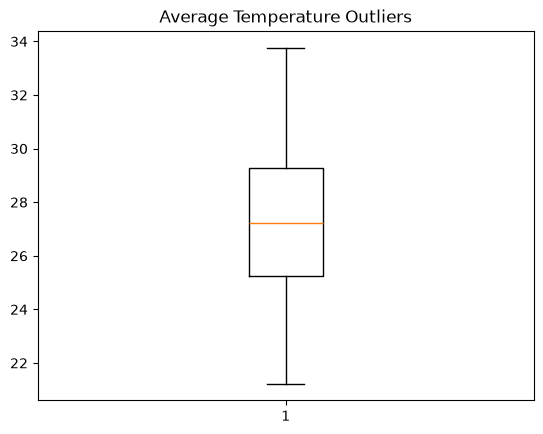

In [172]:
import matplotlib.pyplot as plt

plt.boxplot(df["temperature_avg_c"].dropna())
plt.title("Average Temperature Outliers")
plt.show()

<!-- 03_data_transformation.ipynb -->

In [173]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_year"] = df["date"].dt.dayofyear

<!-- For cyclic weather patterns -->

In [175]:
import numpy as np

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

<!-- seasonal year  -->

In [177]:
df["day_of_year_sin"] = np.sin(
    2 * np.pi * df["day_of_year"] / 365
)

df["day_of_year_cos"] = np.cos(
    2 * np.pi * df["day_of_year"] / 365
)

<!-- 04_feature_engineering.ipynb -->

<!-- temperature -->

In [178]:
df["temperature_range_c"] = (
    df["temperature_max_c"] -
    df["temperature_min_c"]
)

In [179]:
df["temperature_avg_3day_mean"] = (
    df["temperature_avg_c"].rolling(3).mean()
)

df["temperature_avg_7day_mean"] = (
    df["temperature_avg_c"].rolling(7).mean()
)

In [180]:
df["temperature_change_1day"] = (
    df["temperature_avg_c"].diff(1)
)

df["temperature_change_3day"] = (
    df["temperature_avg_c"].diff(3)
)

df["temperature_change_7day"] = (
    df["temperature_avg_c"].diff(7)
)

<!-- dew_point_c -->

In [181]:
df["dew_point_3day_mean"] = (
    df["dew_point_c"].rolling(3).mean()
)

df["dew_point_7day_mean"] = (
    df["dew_point_c"].rolling(7).mean()
)

In [182]:
df["temperature_dewpoint_difference"] = (
    df["temperature_avg_c"] -
    df["dew_point_c"]
)

<!-- relative_humidity_pct -->

In [183]:
df["humidity_3day_mean"] = (
    df["relative_humidity_pct"].rolling(3).mean()
)

df["humidity_7day_mean"] = (
    df["relative_humidity_pct"].rolling(7).mean()
)

df["humidity_change_1day"] = (
    df["relative_humidity_pct"].diff(1)
)

<!-- precipitation_mm -->

In [184]:
df["rainfall_3day_sum"] = (
    df["precipitation_mm"].rolling(3).sum()
)

df["rainfall_7day_sum"] = (
    df["precipitation_mm"].rolling(7).sum()
)

In [185]:
df["rainy_days_7day"] = (
    (df["precipitation_mm"] > 0)
    .rolling(7)
    .sum()
)

<!-- wind_speed_kmh -->

In [186]:
df["wind_speed_3day_mean"] = (
    df["wind_speed_kmh"].rolling(3).mean()
)

df["wind_speed_7day_mean"] = (
    df["wind_speed_kmh"].rolling(7).mean()
)

In [187]:
df["wind_speed_7day_max"] = (
    df["wind_speed_kmh"].rolling(7).max()
)

<!-- peak_wind_gust_kmh -->

In [188]:
df["gust_3day_max"] = (
    df["peak_wind_gust_kmh"].rolling(3).max()
)

df["gust_7day_max"] = (
    df["peak_wind_gust_kmh"].rolling(7).max()
)

<!-- wind direction feature -->

In [189]:
df["wind_direction_sin"] = np.sin(
    2 * np.pi * df["wind_direction_deg"] / 360
)

df["wind_direction_cos"] = np.cos(
    2 * np.pi * df["wind_direction_deg"] / 360
)

<!-- sea_level_pressure_hpa -->

In [190]:
df["pressure_3day_mean"] = (
    df["sea_level_pressure_hpa"].rolling(3).mean()
)

df["pressure_7day_mean"] = (
    df["sea_level_pressure_hpa"].rolling(7).mean()
)

In [191]:
df["pressure_change_1day"] = (
    df["sea_level_pressure_hpa"].diff(1)
)

df["pressure_change_3day"] = (
    df["sea_level_pressure_hpa"].diff(3)
)

<!-- sunshine_minutes -->

In [192]:
df["sunshine_3day_mean"] = (
    df["sunshine_minutes"].rolling(3).mean()
)

df["sunshine_7day_mean"] = (
    df["sunshine_minutes"].rolling(7).mean()
)

<!-- cloud_cover_okta -->

In [193]:
df["cloud_cover_3day_mean"] = (
    df["cloud_cover_okta"].rolling(3).mean()
)

df["cloud_cover_7day_mean"] = (
    df["cloud_cover_okta"].rolling(7).mean()
)

<!-- visibility_m -->

In [194]:
df["visibility_3day_mean"] = (
    df["visibility_m"].rolling(3).mean()
)

df["visibility_7day_mean"] = (
    df["visibility_m"].rolling(7).mean()
)

<!-- Check your new features -->

In [195]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Number of rows: 3653
Number of columns: 62


In [196]:
for i, column in enumerate(df.columns, 1):
    print(i, column)

1 date
2 location
3 station_reference
4 temperature_avg_c
5 temperature_min_c
6 temperature_max_c
7 dew_point_c
8 relative_humidity_pct
9 precipitation_mm
10 snow_depth_mm
11 wind_direction_deg
12 wind_speed_kmh
13 peak_wind_gust_kmh
14 sea_level_pressure_hpa
15 sunshine_minutes
16 cloud_cover_okta
17 visibility_m
18 weather_condition_code
19 temperature_range_c
20 pressure_change_hpa
21 rainfall_3day_mm
22 rainfall_7day_mm
23 next_day_temperature_c
24 year
25 month
26 day
27 day_of_year
28 month_sin
29 month_cos
30 day_of_year_sin
31 day_of_year_cos
32 temperature_avg_3day_mean
33 temperature_avg_7day_mean
34 temperature_change_1day
35 temperature_change_3day
36 temperature_change_7day
37 dew_point_3day_mean
38 dew_point_7day_mean
39 temperature_dewpoint_difference
40 humidity_3day_mean
41 humidity_7day_mean
42 humidity_change_1day
43 rainfall_3day_sum
44 rainfall_7day_sum
45 rainy_days_7day
46 wind_speed_3day_mean
47 wind_speed_7day_mean
48 wind_speed_7day_max
49 gust_3day_max
50 gus

In [197]:
df.isnull().sum()

date                     0
location                 0
station_reference        0
temperature_avg_c        0
temperature_min_c        0
                        ..
sunshine_7day_mean       6
cloud_cover_3day_mean    2
cloud_cover_7day_mean    6
visibility_3day_mean     2
visibility_7day_mean     6
Length: 62, dtype: int64

In [198]:
df = df.dropna().reset_index(drop=True)

In [199]:
df.isnull().sum()

date                     0
location                 0
station_reference        0
temperature_avg_c        0
temperature_min_c        0
                        ..
sunshine_7day_mean       0
cloud_cover_3day_mean    0
cloud_cover_7day_mean    0
visibility_3day_mean     0
visibility_7day_mean     0
Length: 62, dtype: int64

In [200]:
print(df.shape)

(3646, 62)


<!-- 05_dimensional_reduction.ipynb -->

<!-- Standardization and PCA -->

In [202]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_columns = [
    "temperature_avg_c",
    "temperature_min_c",
    "temperature_max_c",
    "dew_point_c",
    "relative_humidity_pct",
    "precipitation_mm",
    "wind_speed_kmh",
    "peak_wind_gust_kmh",
    "sea_level_pressure_hpa",
    "sunshine_minutes",
    "cloud_cover_okta",
    "visibility_m",

    # Temperature features
    "temperature_range_c",
    "temperature_avg_3day_mean",
    "temperature_avg_7day_mean",
    "temperature_change_1day",
    "temperature_change_3day",
    "temperature_change_7day",

    # Dew point features
    "dew_point_3day_mean",
    "dew_point_7day_mean",
    "temperature_dewpoint_difference",

    # Humidity features
    "humidity_3day_mean",
    "humidity_7day_mean",
    "humidity_change_1day",

    # Rainfall features
    "rainfall_3day_sum",
    "rainfall_7day_sum",
    "rainy_days_7day",

    # Wind features
    "wind_speed_3day_mean",
    "wind_speed_7day_mean",
    "wind_speed_7day_max",
    "gust_3day_max",
    "gust_7day_max",
    "wind_direction_sin",
    "wind_direction_cos",

    # Pressure features
    "pressure_3day_mean",
    "pressure_7day_mean",
    "pressure_change_1day",
    "pressure_change_3day",

    # Sunshine
    "sunshine_3day_mean",
    "sunshine_7day_mean",

    # Cloud
    "cloud_cover_3day_mean",
    "cloud_cover_7day_mean",

    # Visibility
    "visibility_3day_mean",
    "visibility_7day_mean",

    # Time features
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

X = df[feature_columns]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X.shape[1])
print("Number of PCA components:", X_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original number of features: 48
Number of PCA components: 21
Explained variance: 0.950995529653558


In [127]:
print("df shape:", df.shape)
print("X shape:", X.shape)
print("X_scaled shape:", X_scaled.shape)
print("X_pca shape:", X_pca.shape)

df shape: (3646, 62)
X shape: (3646, 48)
X_scaled shape: (3646, 48)
X_pca shape: (3646, 21)


<!-- Create Time-Series Sequences -->

In [204]:
df["target_temperature"] = df["temperature_avg_c"].shift(-1)

print(df[[
    "date",
    "temperature_avg_c",
    "target_temperature"
]].head())

        date  temperature_avg_c  target_temperature
0 2015-01-08              22.61               25.23
1 2015-01-09              25.23               23.71
2 2015-01-10              23.71               24.61
3 2015-01-11              24.61               24.06
4 2015-01-12              24.06               24.81


In [206]:
df = df.dropna(subset=["target_temperature"]).reset_index(drop=True)

In [207]:
print("X_pca rows:", len(X_pca))
print("df rows:", len(df))
print("Target rows:", len(df["target_temperature"]))

X_pca rows: 3646
df rows: 3645
Target rows: 3645


In [209]:
df["target_temperature"] = df["temperature_avg_c"].shift(-1)

df = df.dropna(subset=["target_temperature"]).reset_index(drop=True)

print("df rows:", len(df))

df rows: 3643


In [210]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("X shape:", X.shape)
print("X_pca shape:", X_pca.shape)
print("Target shape:", df["target_temperature"].shape)

X shape: (3643, 48)
X_pca shape: (3643, 21)
Target shape: (3643,)


In [217]:
import numpy as np

lookback = 7

X_sequences = []
y_sequences = []

for i in range(lookback, len(X_pca)):
    X_sequences.append(X_pca[i-lookback:i])
    y_sequences.append(df["target_temperature"].iloc[i])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)

X shape: (3636, 7, 21)
y shape: (3636,)


<!-- test/ train split -->

In [218]:
print(df["date"].min())
print(df["date"].max())

2015-01-08 00:00:00
2024-12-28 00:00:00


In [219]:
train_df = df[df["date"].dt.year <= 2022].copy()

val_df = df[df["date"].dt.year == 2023].copy()

test_df = df[df["date"].dt.year == 2024].copy()

In [220]:
print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (2915, 63)
Validation: (365, 63)
Testing: (363, 63)


In [221]:
print(
    "Training:",
    train_df["date"].min(),
    "to",
    train_df["date"].max()
)

print(
    "Validation:",
    val_df["date"].min(),
    "to",
    val_df["date"].max()
)

print(
    "Testing:",
    test_df["date"].min(),
    "to",
    test_df["date"].max()
)

Training: 2015-01-08 00:00:00 to 2022-12-31 00:00:00
Validation: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
Testing: 2024-01-01 00:00:00 to 2024-12-28 00:00:00


In [222]:
train_df = df[df["date"].dt.year <= 2022].copy()

val_df = df[df["date"].dt.year == 2023].copy()

test_df = df[df["date"].dt.year == 2024].copy()

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

print("\nDate ranges:")

print("Training:",
      train_df["date"].min(),
      "to",
      train_df["date"].max())

print("Validation:",
      val_df["date"].min(),
      "to",
      val_df["date"].max())

print("Testing:",
      test_df["date"].min(),
      "to",
      test_df["date"].max())

Training: (2915, 63)
Validation: (365, 63)
Testing: (363, 63)

Date ranges:
Training: 2015-01-08 00:00:00 to 2022-12-31 00:00:00
Validation: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
Testing: 2024-01-01 00:00:00 to 2024-12-28 00:00:00


<!-- Create the Prediction Target -->

In [223]:
df["target_temperature"] = df["temperature_avg_c"].shift(-1)

In [224]:
print(
    df[
        ["date", "temperature_avg_c", "target_temperature"]
    ].head(10)
)

        date  temperature_avg_c  target_temperature
0 2015-01-08              22.61               25.23
1 2015-01-09              25.23               23.71
2 2015-01-10              23.71               24.61
3 2015-01-11              24.61               24.06
4 2015-01-12              24.06               24.81
5 2015-01-13              24.81               24.59
6 2015-01-14              24.59               24.52
7 2015-01-15              24.52               24.26
8 2015-01-16              24.26               23.50
9 2015-01-17              23.50               25.34


In [225]:
df = df.dropna(
    subset=["target_temperature"]
).reset_index(drop=True)

In [226]:
print(df.shape)
print(df.tail())

(3642, 63)
           date         location                    station_reference  \
3637 2024-12-23  Yangon, Myanmar  Yangon International Airport (VYYY)   
3638 2024-12-24  Yangon, Myanmar  Yangon International Airport (VYYY)   
3639 2024-12-25  Yangon, Myanmar  Yangon International Airport (VYYY)   
3640 2024-12-26  Yangon, Myanmar  Yangon International Airport (VYYY)   
3641 2024-12-27  Yangon, Myanmar  Yangon International Airport (VYYY)   

      temperature_avg_c  temperature_min_c  temperature_max_c  dew_point_c  \
3637              24.61              20.43              29.21        22.92   
3638              24.95              21.77              29.40        21.48   
3639              24.21              20.74              29.58        22.03   
3640              23.86              20.07              29.02        22.38   
3641              24.04              20.36              28.30        22.20   

      relative_humidity_pct  precipitation_mm  snow_depth_mm  ...  \
3637        

In [227]:
print(df.tail())

           date         location                    station_reference  \
3637 2024-12-23  Yangon, Myanmar  Yangon International Airport (VYYY)   
3638 2024-12-24  Yangon, Myanmar  Yangon International Airport (VYYY)   
3639 2024-12-25  Yangon, Myanmar  Yangon International Airport (VYYY)   
3640 2024-12-26  Yangon, Myanmar  Yangon International Airport (VYYY)   
3641 2024-12-27  Yangon, Myanmar  Yangon International Airport (VYYY)   

      temperature_avg_c  temperature_min_c  temperature_max_c  dew_point_c  \
3637              24.61              20.43              29.21        22.92   
3638              24.95              21.77              29.40        21.48   
3639              24.21              20.74              29.58        22.03   
3640              23.86              20.07              29.02        22.38   
3641              24.04              20.36              28.30        22.20   

      relative_humidity_pct  precipitation_mm  snow_depth_mm  ...  \
3637                   

<!-- Split the data chronologically -->

In [228]:
train_df = df[
    df["date"].dt.year <= 2022
].copy()

val_df = df[
    df["date"].dt.year == 2023
].copy()

test_df = df[
    df["date"].dt.year == 2024
].copy()

In [229]:
print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (2915, 63)
Validation: (365, 63)
Testing: (362, 63)


In [230]:
print("\nTRAIN")
print(train_df["date"].min())
print(train_df["date"].max())

print("\nVALIDATION")
print(val_df["date"].min())
print(val_df["date"].max())

print("\nTEST")
print(test_df["date"].min())
print(test_df["date"].max())


TRAIN
2015-01-08 00:00:00
2022-12-31 00:00:00

VALIDATION
2023-01-01 00:00:00
2023-12-31 00:00:00

TEST
2024-01-01 00:00:00
2024-12-27 00:00:00


<!-- Create X and y for each dataset -->

In [232]:
X_train = train_df[feature_columns]
y_train = train_df["target_temperature"]

X_val = val_df[feature_columns]
y_val = val_df["target_temperature"]

X_test = test_df[feature_columns]
y_test = test_df["target_temperature"]

In [233]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2915, 48)
y_train: (2915,)
X_val: (365, 48)
y_val: (365,)
X_test: (362, 48)
y_test: (362,)


<!-- Standardization -->

In [235]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

<!-- PCA -->

In [236]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_val_pca = pca.transform(
    X_val_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

In [238]:
print("Training PCA:", X_train_pca.shape)
print("Validation PCA:", X_val_pca.shape)
print("Testing PCA:", X_test_pca.shape)

print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)

Training PCA: (2915, 21)
Validation PCA: (365, 21)
Testing PCA: (362, 21)
Explained variance: 0.9514640647013868


<!-- Create 7-day sequences -->

In [239]:
import numpy as np

def create_sequences(X, y, lookback=7):

    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):

        X_sequences.append(
            X[i-lookback:i]
        )

        y_sequences.append(
            y.iloc[i]
        )

    return (
        np.array(X_sequences),
        np.array(y_sequences)
    )

<!-- Create training sequences -->

In [240]:
X_train_seq, y_train_seq = create_sequences(
    X_train_pca,
    y_train,
    lookback=7
)

In [241]:
X_val_seq, y_val_seq = create_sequences(
    X_val_pca,
    y_val,
    lookback=7
)

In [242]:
X_test_seq, y_test_seq = create_sequences(
    X_test_pca,
    y_test,
    lookback=7
)

<!-- Check the shapes -->

In [244]:
print("Training X:", X_train_seq.shape)
print("Training y:", y_train_seq.shape)

print("Validation X:", X_val_seq.shape)
print("Validation y:", y_val_seq.shape)

print("Testing X:", X_test_seq.shape)
print("Testing y:", y_test_seq.shape)

Training X: (2908, 7, 21)
Training y: (2908,)
Validation X: (358, 7, 21)
Validation y: (358,)
Testing X: (355, 7, 21)
Testing y: (355,)


<!-- Install TensorFlow -->

In [245]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [246]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [248]:
import numpy as np

TIME_STEPS = 7

def create_sequences(X, y, time_steps=7):
    # Convert Pandas data to NumPy arrays
    X = np.asarray(X)
    y = np.asarray(y)

    X_sequences = []
    y_sequences = []

    for i in range(time_steps, len(X)):
        X_sequences.append(X[i-time_steps:i])
        y_sequences.append(y[i])

    return np.array(X_sequences), np.array(y_sequences)


# Create 7-day sequences
X_train_seq, y_train_seq = create_sequences(
    X_train,
    y_train,
    TIME_STEPS
)

X_val_seq, y_val_seq = create_sequences(
    X_val,
    y_val,
    TIME_STEPS
)

X_test_seq, y_test_seq = create_sequences(
    X_test,
    y_test,
    TIME_STEPS
)

In [249]:
print("X_train shape:", X_train_seq.shape)
print("y_train shape:", y_train_seq.shape)

print("X_val shape:", X_val_seq.shape)
print("y_val shape:", y_val_seq.shape)

print("X_test shape:", X_test_seq.shape)
print("y_test shape:", y_test_seq.shape)

X_train shape: (2908, 7, 48)
y_train shape: (2908,)
X_val shape: (358, 7, 48)
y_val shape: (358,)
X_test shape: (355, 7, 48)
y_test shape: (355,)


<!-- Build the basic LSTM -->

In [250]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

model_lstm = Sequential([
    Input(
        shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    ),

    LSTM(64),

    Dense(1)
])

model_lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_lstm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        28,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,993 (113.25 KB)

 Trainable params: 28,993 (113.25 KB)

 Non-trainable params: 0 (0.00 B)

In [251]:
from tensorflow.keras.callbacks import EarlyStopping

In [252]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [253]:
history = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 691.6563 - mae: 26.1809 - val_loss: 630.6656 - val_mae: 24.9938
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 566.6485 - mae: 23.6817 - val_loss: 523.8372 - val_mae: 22.7553
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 480.8176 - mae: 21.7964 - val_loss: 448.7169 - val_mae: 21.0400
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 411.6918 - mae: 20.1500 - val_loss: 379.4898 - val_mae: 19.3244
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 343.5582 - mae: 18.3790 - val_loss: 317.4115 - val_mae: 17.6459
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 287.7766 - mae: 16.7953 - val_loss: 266.2326 - val_mae: 16.1306
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 240.6279 - mae: 15.3274 - val_loss: 222.3580 - val_mae: 14.7079
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 200.2220 - mae: 13.9479 - val_loss: 184.7649 - val_mae: 13.3690
Epoch 9/50
91/91 ━━━━━━━

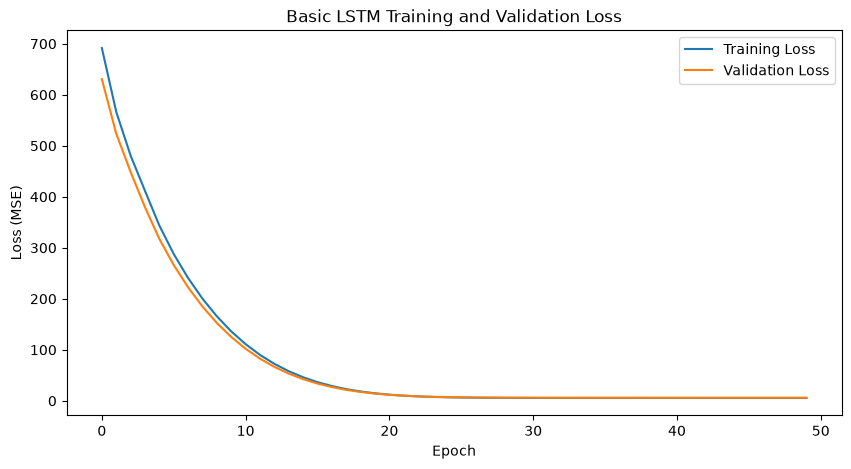

In [254]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Basic LSTM Training and Validation Loss")

plt.legend()
plt.show()

In [255]:
test_loss, test_mae = model_lstm.evaluate(
    X_test_seq,
    y_test_seq,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.2676 - mae: 1.9722 
Test Loss: 5.2675628662109375
Test MAE: 1.9722248315811157


In [256]:
y_pred_scaled = model_lstm.predict(X_test_seq)

print("Prediction shape:", y_pred_scaled.shape)
print("Actual shape:", y_test_seq.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Prediction shape: (355, 1)
Actual shape: (355,)


In [259]:
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()

# Fit ONLY on the training target
target_scaler.fit(
    train_df[["temperature_avg_c"]]
)

StandardScaler()

In [260]:
y_test_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
)

y_pred_actual = target_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
)

print("Actual:", y_test_actual[:5])
print("Predicted:", y_pred_actual[:5])

Actual: [[86.42684805]
 [85.14157849]
 [85.18831557]
 [83.48241234]
 [84.81441897]]
Predicted: [[90.93462 ]
 [90.93462 ]
 [90.93462 ]
 [90.934555]
 [90.934555]]


In [261]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

print("Basic LSTM MAE:", mae, "°C")
print("Basic LSTM RMSE:", rmse, "°C")

Basic LSTM MAE: 4.608801066743981 °C
Basic LSTM RMSE: 5.363352473955503 °C


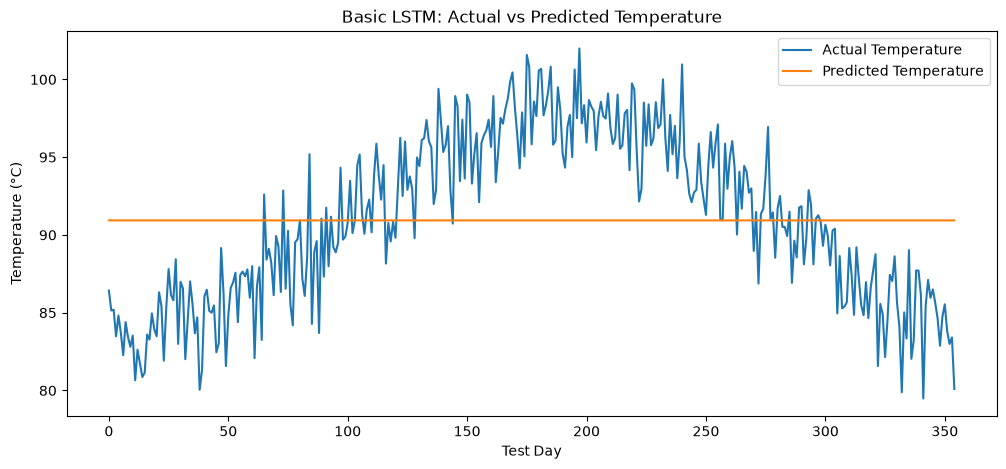

In [262]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual.flatten(),
    label="Actual Temperature"
)

plt.plot(
    y_pred_actual.flatten(),
    label="Predicted Temperature"
)

plt.xlabel("Test Day")
plt.ylabel("Temperature (°C)")
plt.title(
    "Basic LSTM: Actual vs Predicted Temperature"
)

plt.legend()
plt.show()

In [263]:
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("X_val_seq:", X_val_seq.shape)
print("y_val_seq:", y_val_seq.shape)

print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

print("\nFirst 10 scaled target values:")
print(y_test_seq[:10].flatten())

print("\nFirst 10 scaled predictions:")
print(y_pred_scaled[:10].flatten())

print("\nPrediction statistics:")
print("Min:", y_pred_scaled.min())
print("Max:", y_pred_scaled.max())
print("Mean:", y_pred_scaled.mean())
print("Std:", y_pred_scaled.std())

X_train_seq: (2908, 7, 48)
y_train_seq: (2908,)
X_val_seq: (358, 7, 48)
y_val_seq: (358,)
X_test_seq: (355, 7, 48)
y_test_seq: (355,)

First 10 scaled target values:
[25.33 24.78 24.8  24.07 24.64 24.17 23.55 24.46 24.05 23.78]

First 10 scaled predictions:
[27.258995 27.258995 27.258995 27.258963 27.258963 27.258963 27.258963
 27.258963 27.258963 27.258963]

Prediction statistics:
Min: 27.258844
Max: 27.258995
Mean: 27.258984
Std: 3.0397798e-05


In [264]:
print("\nTarget scaler:")
print("Mean:", target_scaler.mean_)
print("Scale:", target_scaler.scale_)


Target scaler:
Mean: [27.23434305]
Scale: [2.33685373]


In [265]:
y_test_actual = y_test_seq.reshape(-1, 1)
y_pred_actual = y_pred_scaled.reshape(-1, 1)

print("First 5 actual:")
print(y_test_actual[:5])

print("\nFirst 5 predicted:")
print(y_pred_actual[:5])

First 5 actual:
[[25.33]
 [24.78]
 [24.8 ]
 [24.07]
 [24.64]]

First 5 predicted:
[[27.258995]
 [27.258995]
 [27.258995]
 [27.258963]
 [27.258963]]


In [266]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

print("Test MAE:", mae, "°C")
print("Test RMSE:", rmse, "°C")

Test MAE: 1.9722250353316186 °C
Test RMSE: 2.295117107945964 °C


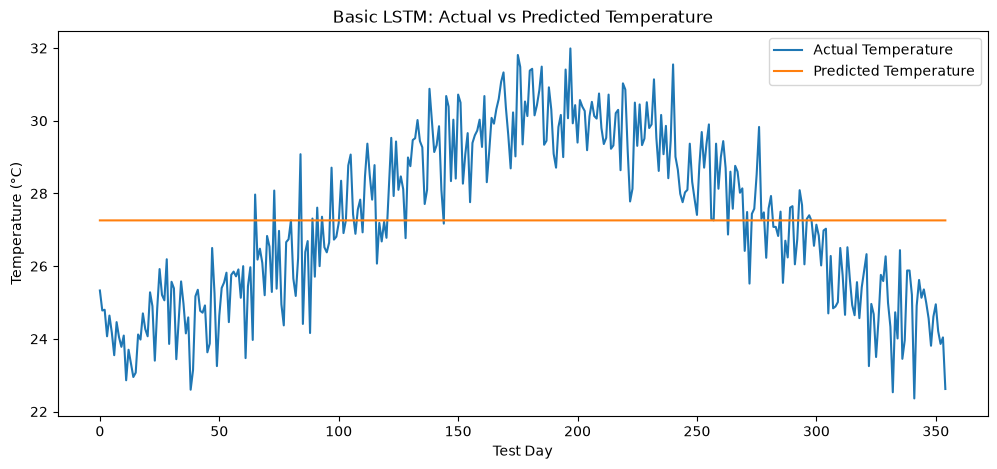

In [267]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual.flatten(),
    label="Actual Temperature"
)

plt.plot(
    y_pred_actual.flatten(),
    label="Predicted Temperature"
)

plt.xlabel("Test Day")
plt.ylabel("Temperature (°C)")
plt.title("Basic LSTM: Actual vs Predicted Temperature")
plt.legend()
plt.show()

In [268]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("Baseline LSTM MAE:", mae)
print("Baseline LSTM RMSE:", rmse)

Baseline LSTM MAE: 1.9722250353316186
Baseline LSTM RMSE: 2.295117107945964


In [269]:
target_scaler
y_test_seq
y_pred_scaled
y_test_actual
y_pred_actual

array([[27.258995],
       [27.258995],
       [27.258995],
       [27.258963],
       [27.258963],
       [27.258963],
       [27.258963],
       [27.258963],
       [27.258963],
       [27.258963],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258844],
       [27.258844],
       [27.258844],
       [27.258844],
       [27.258844],
       [27.258844],
       [27.258844],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],
       [27.258995],


<!-- verify the current data -->

In [270]:
target_scaler = ...

In [271]:
X_train_seq, y_train_seq = ...
X_val_seq, y_val_seq = ...
X_test_seq, y_test_seq = ...

TypeError: cannot unpack non-iterable ellipsis object

In [272]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    Layer,
    Multiply,
    Softmax
)
from tensorflow.keras.callbacks import EarlyStopping

In [273]:
np.random.seed(42)
tf.random.set_seed(42)

In [276]:
file_path = r"../data/raw/Yangon_Weather_2015_2024.csv"

df = pd.read_csv(file_path)

print(df.shape)
print(df.head())
print(df.columns.tolist())

(3653, 23)
         date         location                    station_reference  \
0  2015-01-01  Yangon, Myanmar  Yangon International Airport (VYYY)   
1  2015-01-02  Yangon, Myanmar  Yangon International Airport (VYYY)   
2  2015-01-03  Yangon, Myanmar  Yangon International Airport (VYYY)   
3  2015-01-04  Yangon, Myanmar  Yangon International Airport (VYYY)   
4  2015-01-05  Yangon, Myanmar  Yangon International Airport (VYYY)   

   temperature_avg_c  temperature_min_c  temperature_max_c  dew_point_c  \
0              23.18              19.24              28.96        19.98   
1              25.16              21.42              29.97        20.25   
2              25.55              21.51              29.85        23.84   
3              24.46              21.08              29.55        23.00   
4              23.21              19.04              28.62        21.22   

   relative_humidity_pct  precipitation_mm  snow_depth_mm  ...  \
0                   77.4               0.0   

In [277]:
target_column = "next_day_temperature_c"

In [278]:
print(df[target_column].head(10))
print(df[target_column].isna().sum())

0    25.16
1    25.55
2    24.46
3    23.21
4    25.00
5    23.40
6    22.61
7    25.23
8    23.71
9    24.61
Name: next_day_temperature_c, dtype: float64
1


In [279]:
df = df.dropna(subset=[target_column]).reset_index(drop=True)

In [280]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['temperature_avg_c', 'temperature_min_c', 'temperature_max_c', 'dew_point_c', 'relative_humidity_pct', 'precipitation_mm', 'snow_depth_mm', 'wind_direction_deg', 'wind_speed_kmh', 'peak_wind_gust_kmh', 'sea_level_pressure_hpa', 'sunshine_minutes', 'cloud_cover_okta', 'visibility_m', 'weather_condition_code', 'temperature_range_c', 'pressure_change_hpa', 'rainfall_3day_mm', 'rainfall_7day_mm', 'next_day_temperature_c']


In [281]:
feature_columns = [
    col for col in numeric_columns
    if col != target_column
]

print("Number of input features:", len(feature_columns))
print(feature_columns)

Number of input features: 19
['temperature_avg_c', 'temperature_min_c', 'temperature_max_c', 'dew_point_c', 'relative_humidity_pct', 'precipitation_mm', 'snow_depth_mm', 'wind_direction_deg', 'wind_speed_kmh', 'peak_wind_gust_kmh', 'sea_level_pressure_hpa', 'sunshine_minutes', 'cloud_cover_okta', 'visibility_m', 'weather_condition_code', 'temperature_range_c', 'pressure_change_hpa', 'rainfall_3day_mm', 'rainfall_7day_mm']


In [282]:
df[feature_columns] = df[feature_columns].replace(
    [np.inf, -np.inf],
    np.nan
)

df[feature_columns] = df[feature_columns].interpolate(
    method="linear"
)

df[feature_columns] = df[feature_columns].ffill().bfill()

df[target_column] = df[target_column].interpolate(
    method="linear"
)

df[target_column] = df[target_column].ffill().bfill()

In [283]:
print("Missing values:")
print(df[feature_columns + [target_column]].isna().sum().sum())

Missing values:
0


In [284]:
df["date"] = pd.to_datetime(df["date"])

train_df = df[df["date"].dt.year <= 2022].copy()
val_df = df[df["date"].dt.year == 2023].copy()
test_df = df[df["date"].dt.year == 2024].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (2922, 23)
Validation: (365, 23)
Test: (365, 23)


In [285]:
print(
    train_df["date"].min(),
    train_df["date"].max()
)

print(
    val_df["date"].min(),
    val_df["date"].max()
)

print(
    test_df["date"].min(),
    test_df["date"].max()
)

2015-01-01 00:00:00 2022-12-31 00:00:00
2023-01-01 00:00:00 2023-12-31 00:00:00
2024-01-01 00:00:00 2024-12-30 00:00:00


In [286]:
feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(
    train_df[feature_columns]
)

X_val_scaled = feature_scaler.transform(
    val_df[feature_columns]
)

X_test_scaled = feature_scaler.transform(
    test_df[feature_columns]
)

In [287]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train_scaled.shape[1])
print("PCA features:", X_train_pca.shape[1])

print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)

Original features: 19
PCA features: 11
Explained variance: 0.9533629743190798


In [288]:
target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(
    train_df[[target_column]]
)

y_val_scaled = target_scaler.transform(
    val_df[[target_column]]
)

y_test_scaled = target_scaler.transform(
    test_df[[target_column]]
)

In [289]:
print("First 10 scaled target values:")
print(y_train_scaled[:10].flatten())

First 10 scaled target values:
[-0.88409474 -0.71732599 -1.18342325 -1.71793846 -0.95251269 -1.63669215
 -1.97450576 -0.85416189 -1.50413238 -1.11928143]


In [290]:
LOOKBACK = 7

In [291]:
def create_sequences(X, y, lookback=7):
    X_seq = []
    y_seq = []

    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

In [292]:
X_train_seq, y_train_seq = create_sequences(
    X_train_pca,
    y_train_scaled,
    LOOKBACK
)

X_val_seq, y_val_seq = create_sequences(
    X_val_pca,
    y_val_scaled,
    LOOKBACK
)

X_test_seq, y_test_seq = create_sequences(
    X_test_pca,
    y_test_scaled,
    LOOKBACK
)

In [293]:
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("X_val_seq:", X_val_seq.shape)
print("y_val_seq:", y_val_seq.shape)

print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (2915, 7, 11)
y_train_seq: (2915, 1)
X_val_seq: (358, 7, 11)
y_val_seq: (358, 1)
X_test_seq: (358, 7, 11)
y_test_seq: (358, 1)


In [294]:
def build_baseline_lstm(input_shape):

    inputs = Input(shape=input_shape)

    x = LSTM(64)(inputs)
    x = Dropout(0.2)(x)

    x = Dense(32, activation="relu")(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [295]:
baseline_model = build_baseline_lstm(
    X_train_seq.shape[1:]
)

baseline_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 7, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

In [296]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [297]:
history_baseline = baseline_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2796 - mae: 0.4147 - val_loss: 0.2584 - val_mae: 0.4023
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2121 - mae: 0.3667 - val_loss: 0.2564 - val_mae: 0.4008
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2079 - mae: 0.3629 - val_loss: 0.2543 - val_mae: 0.3970
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2036 - mae: 0.3611 - val_loss: 0.2564 - val_mae: 0.4001
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2007 - mae: 0.3591 - val_loss: 0.2581 - val_mae: 0.4007
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2017 - mae: 0.3581 - val_loss: 0.2558 - val_mae: 0.3994
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2003 - mae: 0.3560 - val_loss: 0.2575 - val_mae: 0.4016
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1961 - mae: 0.3536 - val_loss: 0.2563 - val_mae: 0.3996
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.19

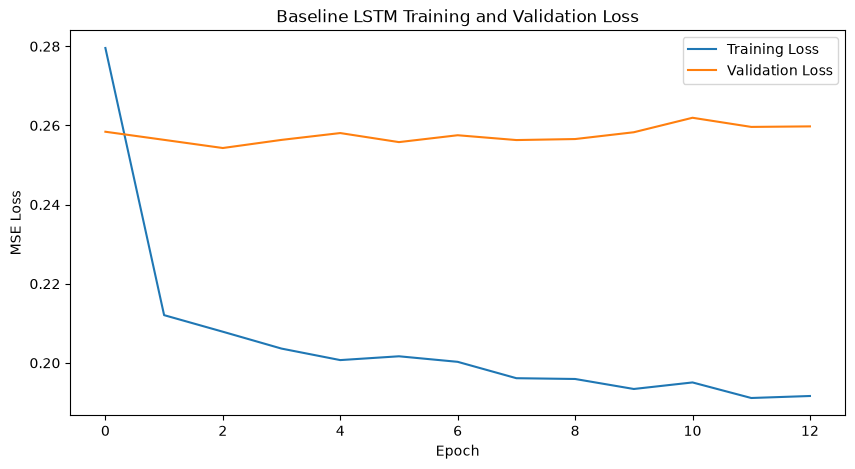

In [298]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_baseline.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_baseline.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Baseline LSTM Training and Validation Loss")
plt.legend()
plt.show()

In [299]:
y_pred_scaled = baseline_model.predict(
    X_test_seq,
    verbose=0
)

In [300]:
y_test_actual = target_scaler.inverse_transform(
    y_test_seq
)

y_pred_actual = target_scaler.inverse_transform(
    y_pred_scaled
)

In [301]:
print("First 5 actual:")
print(y_test_actual[:5])

print("\nFirst 5 predicted:")
print(y_pred_actual[:5])

First 5 actual:
[[25.33]
 [24.78]
 [24.8 ]
 [24.07]
 [24.64]]

First 5 predicted:
[[24.758976]
 [24.559904]
 [24.65276 ]
 [25.330442]
 [25.204765]]


In [302]:
baseline_mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

print("Baseline LSTM MAE:", baseline_mae)
print("Baseline LSTM RMSE:", baseline_rmse)

Baseline LSTM MAE: 0.8021050844245783
Baseline LSTM RMSE: 1.0040373038212633


In [303]:
print(
    "Prediction mean:",
    np.mean(y_pred_actual)
)

print(
    "Prediction std:",
    np.std(y_pred_actual)
)

print(
    "Actual mean:",
    np.mean(y_test_actual)
)

print(
    "Actual std:",
    np.std(y_test_actual)
)

Prediction mean: 27.258642
Prediction std: 2.0183966
Actual mean: 27.26888268156425
Actual std: 2.296469328621185


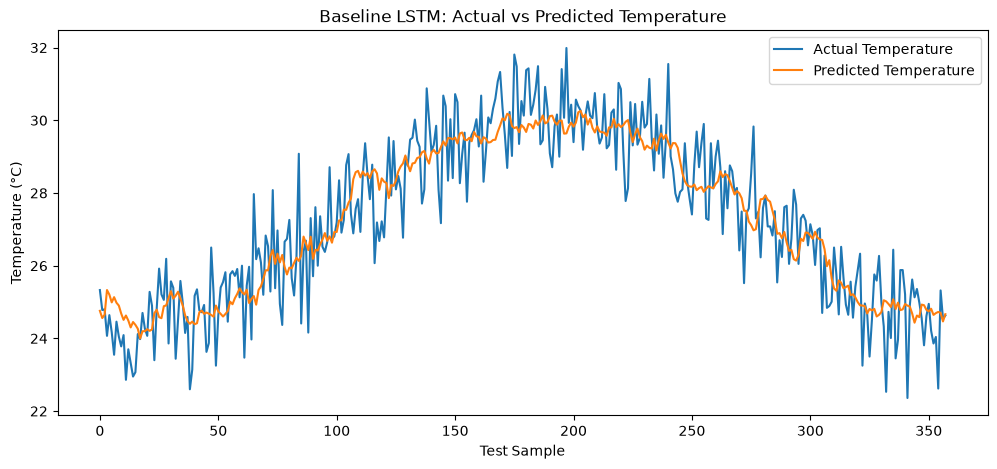

In [304]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual.flatten(),
    label="Actual Temperature"
)

plt.plot(
    y_pred_actual.flatten(),
    label="Predicted Temperature"
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature (°C)")
plt.title("Baseline LSTM: Actual vs Predicted Temperature")
plt.legend()
plt.show()

In [308]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(
    y_test_actual.flatten(),
    y_pred_actual.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual.flatten(),
        y_pred_actual.flatten()
    )
)

r2 = r2_score(
    y_test_actual.flatten(),
    y_pred_actual.flatten()
)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R²:", r2)

Test MAE: 0.8021050844245783
Test RMSE: 1.0040373038212633
Test R²: 0.8088481969839969


In [305]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, Softmax


class FeatureAttention(Layer):

    def __init__(self, **kwargs):
        super(FeatureAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape = (batch, time_steps, features)
        self.feature_score = Dense(1)
        super(FeatureAttention, self).build(input_shape)

    def call(self, inputs):

        # Calculate importance score for each feature
        # Shape: (batch, time_steps, features)
        scores = tf.transpose(inputs, perm=[0, 2, 1])

        scores = self.feature_score(scores)

        # Shape: (batch, features, 1)
        scores = tf.squeeze(scores, axis=-1)

        # Softmax across features
        attention_weights = tf.nn.softmax(
            scores,
            axis=-1
        )

        # Shape: (batch, features, 1)
        attention_weights = tf.expand_dims(
            attention_weights,
            axis=-1
        )

        # Original input
        # (batch, time, features)

        # Convert weights to (batch, 1, features)
        attention_weights = tf.transpose(
            attention_weights,
            perm=[0, 2, 1]
        )

        # Apply feature weights
        weighted_inputs = inputs * attention_weights

        return weighted_inputs

In [306]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model


def build_feature_attention_lstm(input_shape):

    inputs = Input(shape=input_shape)

    # Feature attention
    x = FeatureAttention()(inputs)

    # LSTM
    x = LSTM(64)(x)

    x = Dropout(0.2)(x)

    x = Dense(
        32,
        activation="relu"
    )(x)

    outputs = Dense(1)(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [307]:
feature_attention_model = build_feature_attention_lstm(
    X_train_seq.shape[1:]
)

feature_attention_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 7, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_attention               │ (None, 7, 11)          │             8 │
│ (FeatureAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,577 (84.29 KB)

 Trainable params: 21,577 (84.29 KB)

 Non-trainable params: 0 (0.00 B)

In [309]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [310]:
history_feature_attention = feature_attention_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(
        X_val_seq,
        y_val_seq
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.5520 - mae: 0.6039 - val_loss: 0.3918 - val_mae: 0.5055
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3336 - mae: 0.4574 - val_loss: 0.3666 - val_mae: 0.4843
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3012 - mae: 0.4357 - val_loss: 0.3496 - val_mae: 0.4718
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2802 - mae: 0.4191 - val_loss: 0.3361 - val_mae: 0.4629
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2688 - mae: 0.4114 - val_loss: 0.3305 - val_mae: 0.4593
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2648 - mae: 0.4094 - val_loss: 0.3244 - val_mae: 0.4560
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2568 - mae: 0.4031 - val_loss: 0.3134 - val_mae: 0.4464
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2494 - mae: 0.3968 - val_loss: 0.3105 - val_mae: 0.4437
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.24

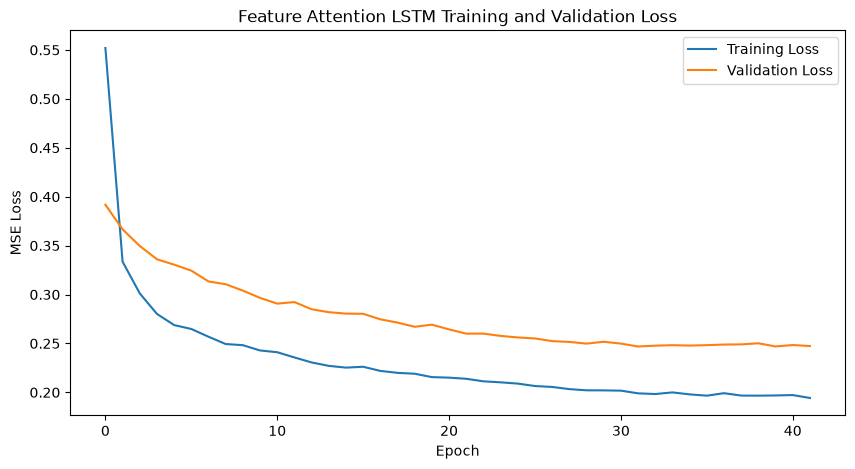

In [311]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_feature_attention.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_feature_attention.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Feature Attention LSTM Training and Validation Loss"
)

plt.legend()
plt.show()

In [312]:
y_pred_feature_scaled = feature_attention_model.predict(
    X_test_seq,
    verbose=0
)

In [313]:
y_pred_feature_actual = target_scaler.inverse_transform(
    y_pred_feature_scaled
)

In [314]:
y_pred_feature_actual = target_scaler.inverse_transform(
    y_pred_feature_scaled
)

In [315]:
feature_attention_mae = mean_absolute_error(
    y_test_actual,
    y_pred_feature_actual
)

feature_attention_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_feature_actual
    )
)

print(
    "Feature Attention MAE:",
    feature_attention_mae
)

print(
    "Feature Attention RMSE:",
    feature_attention_rmse
)

Feature Attention MAE: 0.8154276388583902
Feature Attention RMSE: 1.0285651128043494


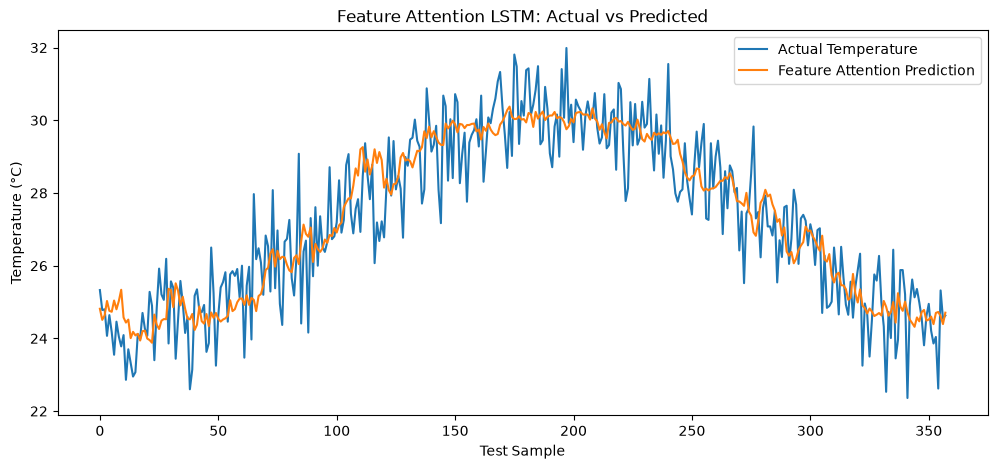

In [316]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual.flatten(),
    label="Actual Temperature"
)

plt.plot(
    y_pred_feature_actual.flatten(),
    label="Feature Attention Prediction"
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature (°C)")

plt.title(
    "Feature Attention LSTM: Actual vs Predicted"
)

plt.legend()
plt.show()

In [317]:
class TemporalAttention(Layer):

    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(
            **kwargs
        )

    def build(self, input_shape):

        self.score_dense = Dense(1)

        super(TemporalAttention, self).build(
            input_shape
        )

    def call(self, inputs):

        # inputs:
        # (batch, time, hidden_features)

        scores = self.score_dense(inputs)

        # (batch, time, 1)

        attention_weights = tf.nn.softmax(
            scores,
            axis=1
        )

        # Weighted hidden states
        weighted = inputs * attention_weights

        # Sum across time
        context = tf.reduce_sum(
            weighted,
            axis=1
        )

        return context

In [318]:
def build_temporal_attention_lstm(input_shape):

    inputs = Input(shape=input_shape)

    # Return all hidden states
    x = LSTM(
        64,
        return_sequences=True
    )(inputs)

    # Temporal attention
    x = TemporalAttention()(x)

    x = Dropout(0.2)(x)

    x = Dense(
        32,
        activation="relu"
    )(x)

    outputs = Dense(1)(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [319]:
temporal_attention_model = build_temporal_attention_lstm(
    X_train_seq.shape[1:]
)

temporal_attention_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 7, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 7, 64)          │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ (None, 64)             │            65 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,634 (84.51 KB)

 Trainable params: 21,634 (84.51 KB)

 Non-trainable params: 0 (0.00 B)

In [320]:
history_temporal_attention = temporal_attention_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(
        X_val_seq,
        y_val_seq
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3025 - mae: 0.4313 - val_loss: 0.2663 - val_mae: 0.4137
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2099 - mae: 0.3651 - val_loss: 0.2641 - val_mae: 0.4117
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2054 - mae: 0.3621 - val_loss: 0.2648 - val_mae: 0.4119
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2034 - mae: 0.3595 - val_loss: 0.2637 - val_mae: 0.4110
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2022 - mae: 0.3588 - val_loss: 0.2627 - val_mae: 0.4099
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2026 - mae: 0.3599 - val_loss: 0.2625 - val_mae: 0.4095
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1985 - mae: 0.3548 - val_loss: 0.2671 - val_mae: 0.4145
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1972 - mae: 0.3560 - val_loss: 0.2654 - val_mae: 0.4123
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 

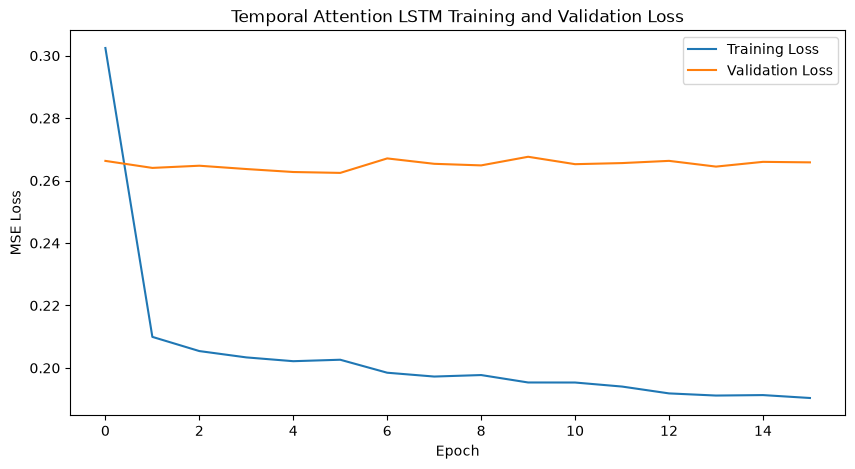

In [321]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_temporal_attention.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_temporal_attention.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Temporal Attention LSTM Training and Validation Loss"
)

plt.legend()
plt.show()

In [322]:
y_pred_temporal_scaled = temporal_attention_model.predict(
    X_test_seq,
    verbose=0
)

In [323]:
y_pred_temporal_actual = target_scaler.inverse_transform(
    y_pred_temporal_scaled
)

In [324]:
temporal_attention_mae = mean_absolute_error(
    y_test_actual,
    y_pred_temporal_actual
)

temporal_attention_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_temporal_actual
    )
)

print(
    "Temporal Attention MAE:",
    temporal_attention_mae
)

print(
    "Temporal Attention RMSE:",
    temporal_attention_rmse
)

Temporal Attention MAE: 0.8107074731155478
Temporal Attention RMSE: 1.0070346538216224


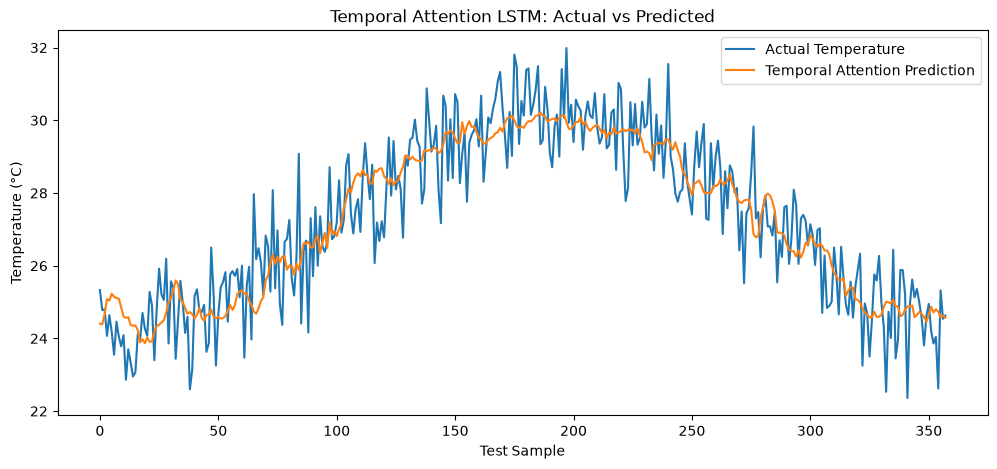

In [325]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual.flatten(),
    label="Actual Temperature"
)

plt.plot(
    y_pred_temporal_actual.flatten(),
    label="Temporal Attention Prediction"
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature (°C)")

plt.title(
    "Temporal Attention LSTM: Actual vs Predicted"
)

plt.legend()
plt.show()

In [327]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

actual = y_test_actual.flatten()

results = []

models = {
    "Basic LSTM": y_pred_actual.flatten(),
    "Feature Attention LSTM": y_pred_feature_actual.flatten(),
    "Temporal Attention LSTM": y_pred_temporal_actual.flatten()
}

for name, pred in models.items():

    mae = mean_absolute_error(actual, pred)

    rmse = np.sqrt(
        mean_squared_error(actual, pred)
    )

    r2 = r2_score(actual, pred)

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R²"]
)

print(results_df)

                     Model       MAE      RMSE        R²
0               Basic LSTM  0.802105  1.004037  0.808848
1   Feature Attention LSTM  0.815428  1.028565  0.799395
2  Temporal Attention LSTM  0.810707  1.007035  0.807705


In [328]:
class HiddenStateScaling(Layer):

    def __init__(self, units, **kwargs):
        super(HiddenStateScaling, self).__init__(
            **kwargs
        )

        self.units = units

    def build(self, input_shape):

        self.scaling_dense = Dense(
            input_shape[-1],
            activation="sigmoid"
        )

        super(HiddenStateScaling, self).build(
            input_shape
        )

    def call(self, inputs):

        # inputs:
        # (batch, time, features)

        # Get a summary of the sequence
        hidden_state = tf.reduce_mean(
            inputs,
            axis=1
        )

        # Generate feature scaling values
        scaling_weights = self.scaling_dense(
            hidden_state
        )

        # Shape:
        # (batch, features)

        scaling_weights = tf.expand_dims(
            scaling_weights,
            axis=1
        )

        # Shape:
        # (batch, 1, features)

        scaled_inputs = inputs * (
            1.0 + scaling_weights
        )

        return scaled_inputs

In [329]:
def build_hidden_state_scaling_lstm(input_shape):

    inputs = Input(shape=input_shape)

    x = HiddenStateScaling(
        units=64
    )(inputs)

    x = LSTM(64)(x)

    x = Dropout(0.2)(x)

    x = Dense(
        32,
        activation="relu"
    )(x)

    outputs = Dense(1)(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [330]:
hidden_scaling_model = build_hidden_state_scaling_lstm(
    X_train_seq.shape[1:]
)

hidden_scaling_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 7, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_state_scaling            │ (None, 7, 11)          │           132 │
│ (HiddenStateScaling)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,701 (84.77 KB)

 Trainable params: 21,701 (84.77 KB)

 Non-trainable params: 0 (0.00 B)

In [331]:
history_hidden_scaling = hidden_scaling_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(
        X_val_seq,
        y_val_seq
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2584 - mae: 0.4024 - val_loss: 0.2608 - val_mae: 0.4072
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2136 - mae: 0.3669 - val_loss: 0.2528 - val_mae: 0.3984
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2076 - mae: 0.3631 - val_loss: 0.2579 - val_mae: 0.4046
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2029 - mae: 0.3587 - val_loss: 0.2530 - val_mae: 0.3998
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2036 - mae: 0.3603 - val_loss: 0.2509 - val_mae: 0.3970
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1999 - mae: 0.3573 - val_loss: 0.2546 - val_mae: 0.4003
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1952 - mae: 0.3511 - val_loss: 0.2573 - val_mae: 0.4021
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1969 - mae: 0.3551 - val_loss: 0.2529 - val_mae: 0.3969
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.19

In [332]:
y_pred_hidden_scaled = hidden_scaling_model.predict(
    X_test_seq,
    verbose=0
)

y_pred_hidden_actual = target_scaler.inverse_transform(
    y_pred_hidden_scaled
)

In [333]:
hidden_scaling_mae = mean_absolute_error(
    y_test_actual,
    y_pred_hidden_actual
)

hidden_scaling_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_hidden_actual
    )
)

print(
    "Hidden-State Scaling MAE:",
    hidden_scaling_mae
)

print(
    "Hidden-State Scaling RMSE:",
    hidden_scaling_rmse
)

Hidden-State Scaling MAE: 0.8033110118844655
Hidden-State Scaling RMSE: 1.006235821236162


In [334]:
def build_final_model(input_shape):

    inputs = Input(shape=input_shape)

    # --------------------------------
    # 1. Hidden-state feature scaling
    # --------------------------------

    x = HiddenStateScaling(
        units=64
    )(inputs)

    # --------------------------------
    # 2. Feature attention
    # --------------------------------

    x = FeatureAttention()(x)

    # --------------------------------
    # 3. LSTM
    # --------------------------------

    x = LSTM(
        64,
        return_sequences=True
    )(x)

    # --------------------------------
    # 4. Temporal attention
    # --------------------------------

    x = TemporalAttention()(x)

    # --------------------------------
    # 5. Fully connected layers
    # --------------------------------

    x = Dropout(0.2)(x)

    x = Dense(
        32,
        activation="relu"
    )(x)

    outputs = Dense(1)(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [335]:
final_model = build_final_model(
    X_train_seq.shape[1:]
)

final_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 7, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_state_scaling_1          │ (None, 7, 11)          │           132 │
│ (HiddenStateScaling)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_attention_1             │ (None, 7, 11)          │             8 │
│ (FeatureAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 7, 64)          │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention_1            │ (None, 64)             │            65 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,774 (85.05 KB)

 Trainable params: 21,774 (85.05 KB)

 Non-trainable params: 0 (0.00 B)

In [336]:
history_final = final_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(
        X_val_seq,
        y_val_seq
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.7424 - mae: 0.7209 - val_loss: 0.5952 - val_mae: 0.6184
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4751 - mae: 0.5521 - val_loss: 0.4430 - val_mae: 0.5299
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3667 - mae: 0.4817 - val_loss: 0.4041 - val_mae: 0.5153
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3219 - mae: 0.4511 - val_loss: 0.3827 - val_mae: 0.5016
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3038 - mae: 0.4397 - val_loss: 0.3729 - val_mae: 0.4956
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2929 - mae: 0.4305 - val_loss: 0.3644 - val_mae: 0.4893
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2856 - mae: 0.4251 - val_loss: 0.3553 - val_mae: 0.4832
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2768 - mae: 0.4180 - val_loss: 0.3506 - val_mae: 0.4804
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2

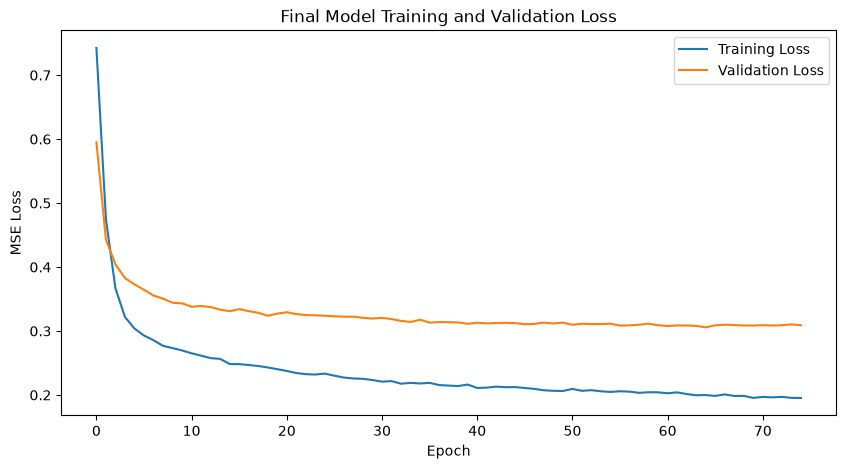

In [337]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_final.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_final.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Final Model Training and Validation Loss"
)

plt.legend()
plt.show()

In [338]:
y_pred_final_scaled = final_model.predict(
    X_test_seq,
    verbose=0
)

In [339]:
y_pred_final_actual = target_scaler.inverse_transform(
    y_pred_final_scaled
)

In [340]:
final_mae = mean_absolute_error(
    y_test_actual,
    y_pred_final_actual
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_final_actual
    )
)

print(
    "Final Model MAE:",
    final_mae
)

print(
    "Final Model RMSE:",
    final_rmse
)

Final Model MAE: 0.887631356436447
Final Model RMSE: 1.1067245668552266


In [341]:
results = pd.DataFrame({
    "Model": [
        "Baseline LSTM",
        "Hidden-State Scaling LSTM",
        "Feature Attention LSTM",
        "Temporal Attention LSTM",
        "Final Adaptive Scaling + Attention"
    ],

    "MAE": [
        baseline_mae,
        hidden_scaling_mae,
        feature_attention_mae,
        temporal_attention_mae,
        final_mae
    ],

    "RMSE": [
        baseline_rmse,
        hidden_scaling_rmse,
        feature_attention_rmse,
        temporal_attention_rmse,
        final_rmse
    ]
})

print(results)

                                Model       MAE      RMSE
0                       Baseline LSTM  0.802105  1.004037
1           Hidden-State Scaling LSTM  0.803311  1.006236
2              Feature Attention LSTM  0.815428  1.028565
3             Temporal Attention LSTM  0.810707  1.007035
4  Final Adaptive Scaling + Attention  0.887631  1.106725


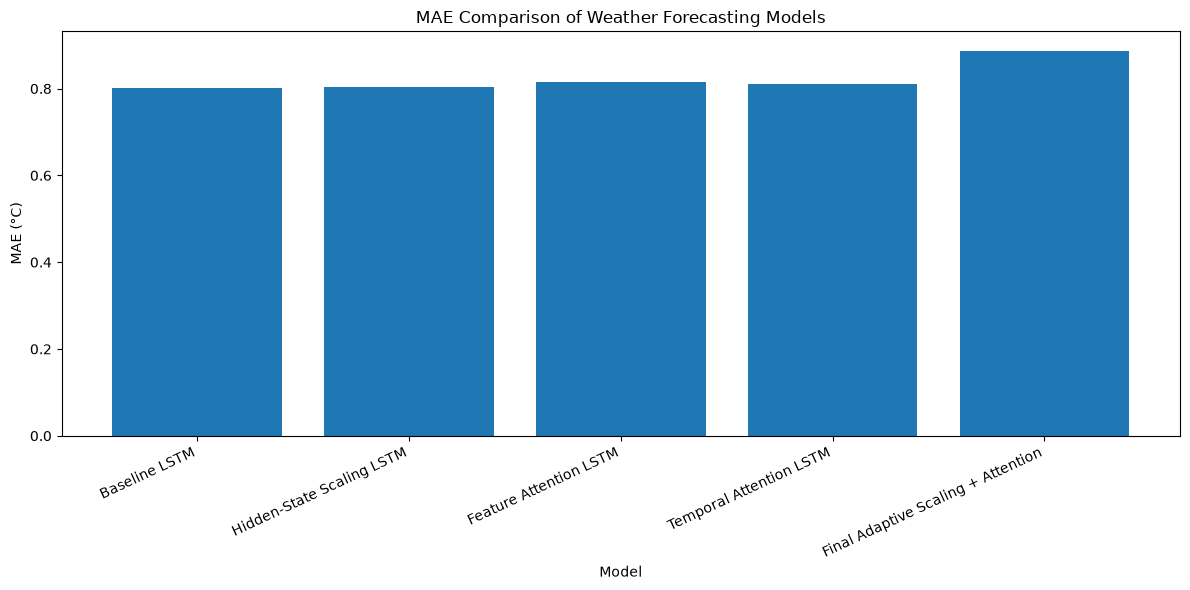

In [342]:
plt.figure(figsize=(12, 6))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE (°C)")

plt.title(
    "MAE Comparison of Weather Forecasting Models"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

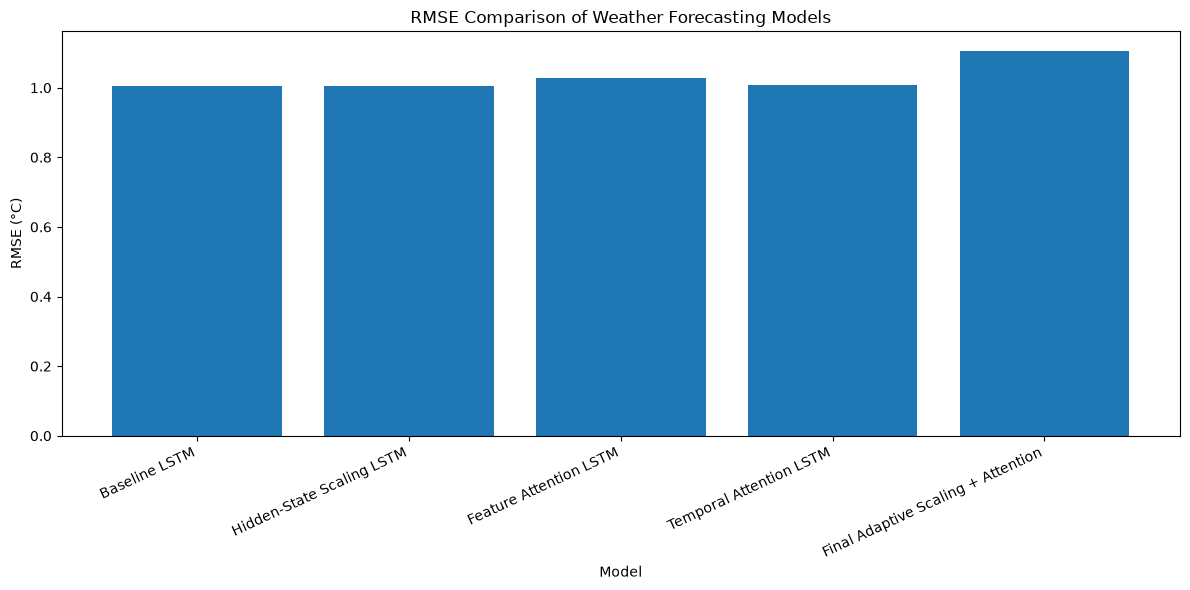

In [343]:
plt.figure(figsize=(12, 6))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE (°C)")

plt.title(
    "RMSE Comparison of Weather Forecasting Models"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

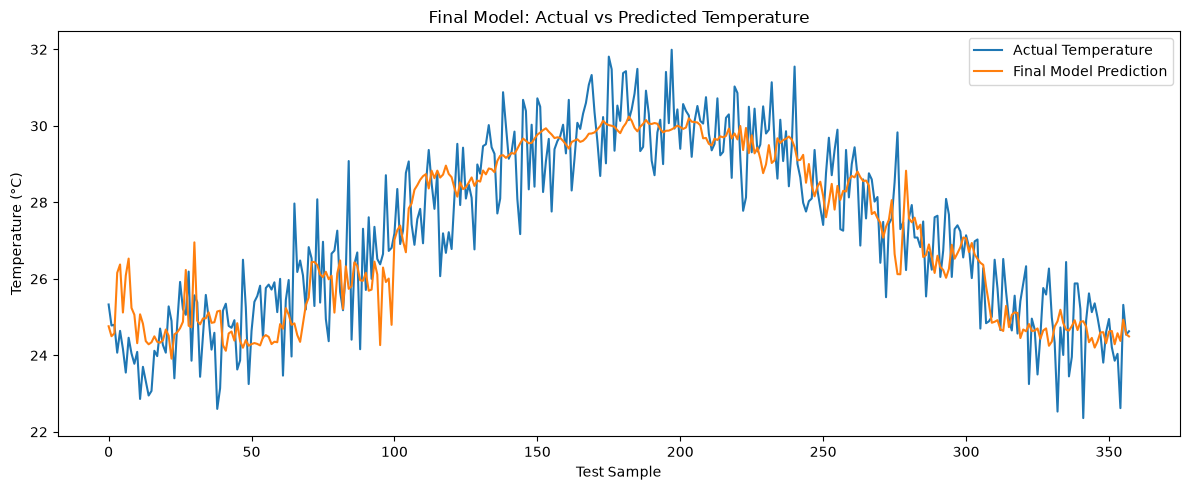

In [344]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual.flatten(),
    label="Actual Temperature"
)

plt.plot(
    y_pred_final_actual.flatten(),
    label="Final Model Prediction"
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature (°C)")

plt.title(
    "Final Model: Actual vs Predicted Temperature"
)

plt.legend()
plt.tight_layout()

plt.show()

In [346]:
results.to_csv(
    r"D:\Yangon Weather Analysis\Yangon-Weather-Forecasting-Using-LSTM-with-Feature-and-Temporal-Attention\results\metrics\model_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [347]:
final_model.save(
    r"D:\Yangon Weather Analysis\Yangon-Weather-Forecasting-Using-LSTM-with-Feature-and-Temporal-Attention\models\final_weather_model.keras"
)

print("Final model saved successfully.")

Final model saved successfully.


In [348]:
prediction_results = pd.DataFrame({
    "Actual_Temperature": y_test_actual.flatten(),
    "Predicted_Temperature": y_pred_final_actual.flatten()
})

prediction_results.to_csv(
    r"D:\Yangon Weather Analysis\Yangon-Weather-Forecasting-Using-LSTM-with-Feature-and-Temporal-Attention\results\metrics\final_predictions.csv",
    index=False
)

print("Predictions saved successfully.")

Predictions saved successfully.


In [349]:
print("=" * 60)
print("YANGON WEATHER FORECASTING PROJECT RESULTS")
print("=" * 60)

print("\nDataset:")
print("Train sequences:", X_train_seq.shape)
print("Validation sequences:", X_val_seq.shape)
print("Test sequences:", X_test_seq.shape)

print("\nPCA:")
print("Number of PCA features:", X_train_seq.shape[2])

print("\nLookback:")
print("Number of previous days:", X_train_seq.shape[1])

print("\nModel Results:")
print(results.to_string(index=False))

print("\nFinal Model:")
print("MAE :", final_mae)
print("RMSE:", final_rmse)

print("=" * 60)

YANGON WEATHER FORECASTING PROJECT RESULTS

Dataset:
Train sequences: (2915, 7, 11)
Validation sequences: (358, 7, 11)
Test sequences: (358, 7, 11)

PCA:
Number of PCA features: 11

Lookback:
Number of previous days: 7

Model Results:
                             Model      MAE     RMSE
                     Baseline LSTM 0.802105 1.004037
         Hidden-State Scaling LSTM 0.803311 1.006236
            Feature Attention LSTM 0.815428 1.028565
           Temporal Attention LSTM 0.810707 1.007035
Final Adaptive Scaling + Attention 0.887631 1.106725

Final Model:
MAE : 0.887631356436447
RMSE: 1.1067245668552266
